**✅ Task 5: Exploratory Data Analysis (EDA) – Titanic Dataset**

**🎯 Objective:**

**Extract insights using visual and statistical exploration. **

**🛠️ Tools Used:**
**Python**

**Pandas**

**Matplotlib**

**Seaborn**

1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

**2. Load  Data**

In [2]:
df = pd.read_excel("/content/Titanic.csv.xlsx")

**3. Explore train.csv (Main EDA Focus)**

**a. Basic Summary**

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,1,1,1,1,1.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.384961,2.306397,29.669706,0.523008,0.381594,32.204208
std,257.353842,0.486859,0.836897,14.563320,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**Value counts**

In [8]:
df['Sex'].value_counts()

,count
Sex,
male,576
female,314
1,1


In [9]:
df['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [10]:
df['Pclass'].value_counts()

,count
Pclass,
3,490
1,217
2,184


**Data Cleaning**

In [11]:
# Fill missing Age values with median
df['Age'].fillna(df['Age'].median(), inplace=True)

<ipython-input-11-058a0070fbe6>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [12]:
# Drop Cabin (if mostly null)
df.drop(columns='Cabin', inplace=True, errors='ignore')

In [13]:
# Drop any remaining rows with missing Embarked
df.dropna(subset=['Embarked'], inplace=True)

**2. Univariate Analysis (Single Variable)**

**🛠️ Histograms and Countplots **

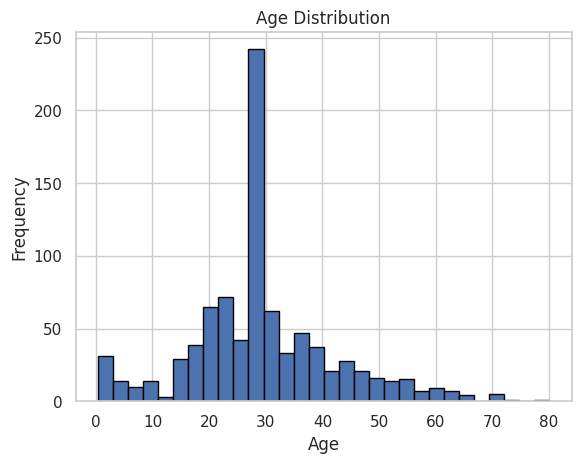

In [14]:
# Age distribution
df['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

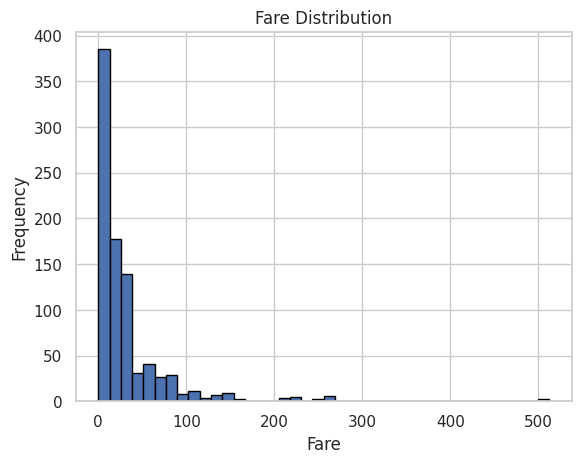

In [15]:
# Fare distribution
df['Fare'].hist(bins=40, edgecolor='black')
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

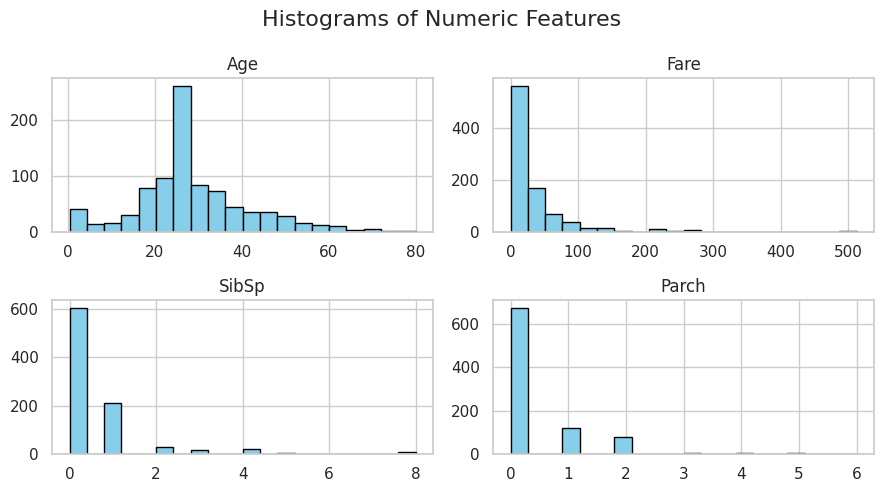

In [33]:
# Plot histograms for numeric columns
df[['Age', 'Fare', 'SibSp', 'Parch']].hist(bins=20, figsize=(9, 5), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numeric Features', fontsize=16)
plt.tight_layout()
plt.show()

Explanation of above graph:

1.)Age Distribution:

The age distribution is right-skewed, with a peak around 20-30 years old.

There is a significant number of younger individuals (20-40 years old).

The frequency decreases as age increases, with fewer older passengers (60+ years old).


2.)Fare Distribution:

The fare distribution is highly right-skewed, with a long tail on the higher end.

The majority of fares are concentrated in the lower range, with a peak around 0-100.

There are a few outliers or extreme values at the higher end of the fare spectrum, potentially representing first-class or other premium tickets.

3.)SibSp (Siblings/Spouses) Distribution:

The SibSp distribution is heavily concentrated around 0, indicating that most passengers were traveling alone or with very few companions.

There is a smaller peak around 2-3 siblings/spouses, suggesting some passengers were traveling with a small group.

4.)Parch (Parents/Children) Distribution:

The Parch distribution is also heavily concentrated around 0, indicating that most passengers were traveling without parents or children.

There is a smaller peak around 1-2 parents/children, suggesting some passengers were traveling with a small family.


**# Countplots for categorical variables**

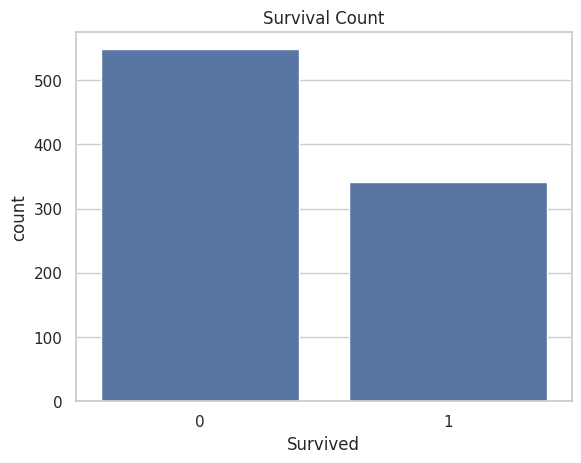

In [17]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

Explanation of above graph:

1.)Survival Status:
 The plot displays the count of passengers who survived (1) and those who did not survive (0) the Titanic disaster.

2.)Survival Counts:

The majority of passengers did not survive, as indicated by the much taller bar for the "0" (did not survive) category.

The count of passengers who survived is significantly lower than those who did not, as shown by the shorter bar for the "1" (survived) category.

3.)Interpretation:

The plot suggests that a large proportion of passengers on the Titanic did not survive the incident.

The imbalance between the survival and non-survival counts indicates that the Titanic disaster had a significant impact on the passengers, with a much higher number of casualties compared to survivors.

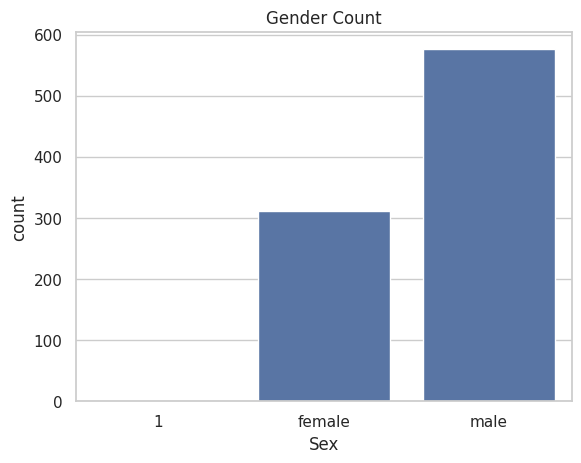

In [18]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Count")
plt.show()

Explanation of above graph:

1. Gender Breakdown:

The plot displays the count of male and female passengers on the Titanic.

The bar for "male" passengers is significantly taller than the bar for "female" passengers, indicating a higher number of male passengers.

2. Gender Counts:

The count of male passengers is around 600, while the count of female passengers is around 300.

The difference in height between the two bars suggests that there were approximately twice as many male passengers as female passengers on the Titanic.

3. Interpretation:

The plot reveals a clear gender imbalance among the Titanic passengers, with a higher proportion of male passengers compared to female passengers.

This observation aligns with historical accounts of the Titanic disaster, where the social norms and customs of the time often prioritized the evacuation of women and children over men.

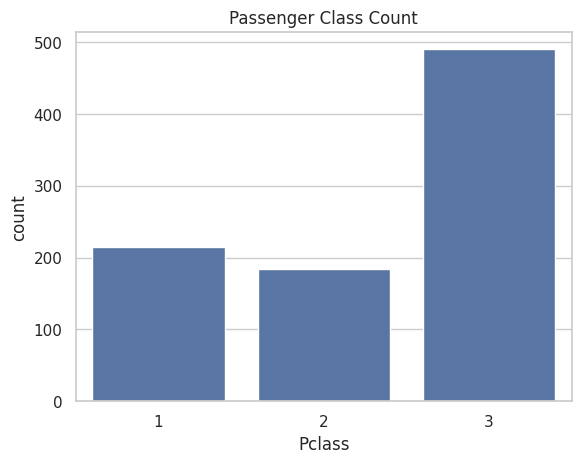

In [19]:
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Count")
plt.show()

Explanation of above graph:

1. Passenger Class Breakdown:

The plot displays the count of passengers in each of the three passenger classes: 1st class, 2nd class, and 3rd class.

The bar for 3rd class passengers is the tallest, indicating that the majority of passengers were in the 3rd class.

2. Passenger Class Counts:

The count of 3rd class passengers is around 400, which is significantly higher than the counts for 1st class (around 200) and 2nd class (around 100) passengers.

The difference in height between the bars suggests a clear hierarchy in the distribution of passengers across the three classes, with a larger proportion of passengers in the lower classes.

3.)Interpretation:

The plot reveals the socioeconomic stratification among the Titanic passengers, with a disproportionately higher number of passengers in the lower-class cabins compared to the upper-class accommodations.

This observation aligns with the historical context of the Titanic, where the social class system of the time was reflected in the passenger distribution on the ship.

🔗 3. Bivariate Analysis (Relationships Between Two Variables)

🛠️ Boxplots, Countplots, Group Comparisons

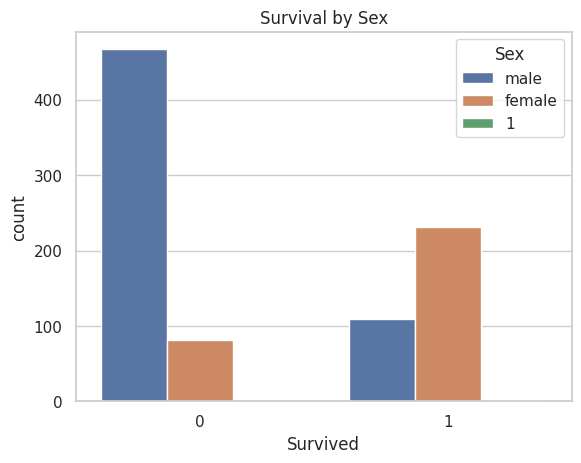

In [20]:
# Survival by Gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title("Survival by Sex")
plt.show()

Explanation of above graph:

1. Survival Rates by Gender:

The plot displays the survival counts for male and female passengers on the Titanic.

The bar for male passengers who survived is significantly shorter than the bar for male passengers who did not survive, indicating a lower survival rate for men.

In contrast, the bar for female passengers who survived is taller than the bar for those who did not survive, suggesting a higher survival rate for women.

2. Survival Counts:

The count of male passengers who did not survive is around 400, which is much higher than the count of male passengers who survived (around 100).

For female passengers, the count of those who survived is around 300, while the count of those who did not survive is around 100.

3. Interpretation:

The plot reveals a clear gender disparity in the survival rates of Titanic passengers, with women having a significantly higher chance of survival compared to men.

This observation aligns with the historical accounts of the Titanic disaster, where the social norms and customs of the time prioritized the evacuation of women and children over men.

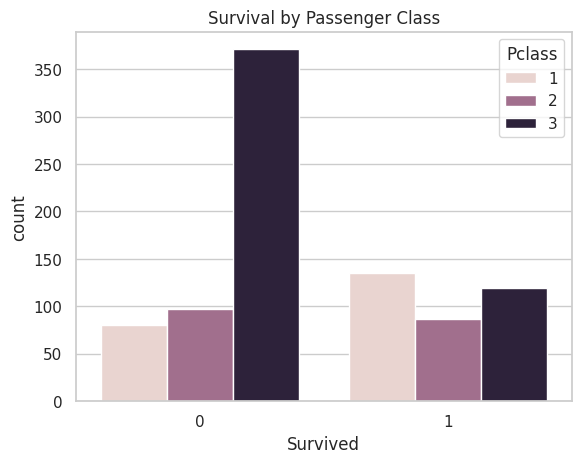

In [21]:
# Survival by Pclass
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title("Survival by Passenger Class")
plt.show()

Explanation of above graph:

1. Survival Rates by Passenger Class:

The plot displays the survival counts for passengers in the 1st, 2nd, and 3rd passenger classes.

The bar for 3rd class passengers who did not survive is significantly taller than the bars for the other two classes, indicating a much lower survival rate for 3rd class passengers.

In contrast, the bar for 1st class passengers who survived is taller than the bar for those who did not survive, suggesting a higher survival rate for 1st class passengers.

2. Survival Counts:

The count of 3rd class passengers who did not survive is around 300, which is much higher than the counts for 1st class (around 50) and 2nd class (around 100) passengers who did not survive.

For 1st class passengers, the count of those who survived is around 100, while the count of those who did not survive is around 50.

3. Interpretation:

The plot reveals a clear class disparity in the survival rates of Titanic passengers, with 1st class passengers having a significantly higher chance of survival compared to 3rd class passengers.

This observation aligns with the historical accounts of the Titanic disaster, where the social class system and the limited number of lifeboats on the ship contributed to the disproportionate survival rates across different passenger classes.

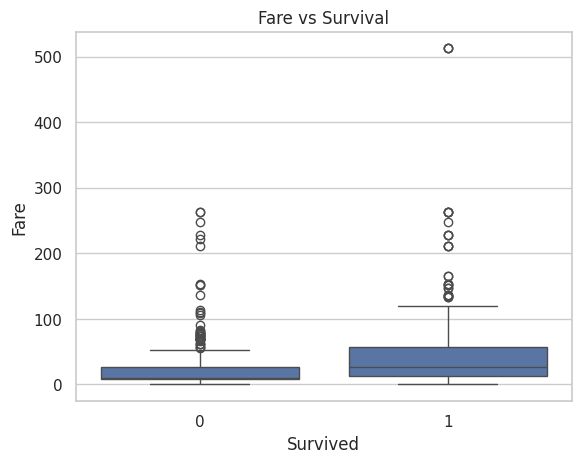

In [22]:
# Fare vs Survival
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

Explanation of above graph:

1. Fare Distribution by Survival Status:

The plot displays the distribution of fares paid by passengers who survived (1) and those who did not survive (0).

For passengers who did not survive, the fare distribution has a wider range, with some outliers at higher fare values.

For passengers who survived, the fare distribution is more concentrated, with the majority of fares falling within a narrower range.

2. Median Fare Comparison:

The median fare for passengers who survived (indicated by the horizontal line within the box) is higher than the median fare for those who did not survive.

This suggests that passengers who paid higher fares had a better chance of surviving the Titanic disaster.

3. Interpretation:

The plot reveals a clear correlation between the fare paid by passengers and their likelihood of survival.

Passengers who could afford higher-class tickets, and thus paid higher fares, seem to have had a better chance of surviving the sinking of the Titanic.

This observation aligns with the historical accounts of the Titanic disaster, where the limited number of lifeboats and the prioritization of first-class passengers during the evacuation contributed to the disparities in survival rates across different passenger classes.

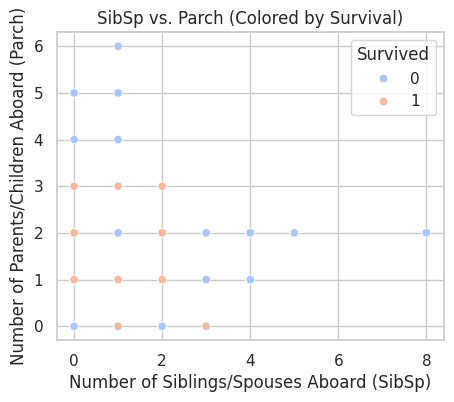

In [34]:
# Scatter plot: SibSp vs. Parch
plt.figure(figsize=(5, 4))
sns.scatterplot(x='SibSp', y='Parch', data=df, hue='Survived', palette='coolwarm')
plt.title('SibSp vs. Parch (Colored by Survival)')
plt.xlabel('Number of Siblings/Spouses Aboard (SibSp)')
plt.ylabel('Number of Parents/Children Aboard (Parch)')
plt.grid(True)
plt.legend(title='Survived', loc='upper right')
plt.show()

explanation of above graph:
1.Survival Status Visualization:

The plot uses a color-coding scheme to distinguish between passengers who survived (blue) and those who did not (orange).

This allows for a clear visual comparison of the distribution of data points between the two survival groups.

2. Relationship between SibSp and Parch:

The scatter plot shows the relationship between the number of siblings/spouses aboard (SibSp) and the number of parents/children aboard (Parch) for each passenger.

The data points are scattered across the plot, indicating that there is no strong linear correlation between these two variables.

3. Survival Patterns:

The blue data points (survived passengers) are more concentrated in the lower-left quadrant of the plot, indicating that passengers with fewer siblings/spouses and fewer parents/children aboard had a higher chance of survival.

Conversely, the orange data points (non-survived passengers) are more widely distributed across the plot, suggesting that passengers with a wider range of family sizes had a lower chance of survival.

3. Interpretation:

The scatter plot reveals that the survival of Titanic passengers was not solely dependent on the number of family members aboard, but rather a complex interplay of various factors.

However, the clustering of survived passengers in the lower-left quadrant suggests that having fewer immediate family members aboard may have increased one's chances of survival during the disaster.

Boxplots (to compare distributions across categories)

 Boxplot of Fare by Pclass**

<ipython-input-24-2524f777210d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, palette='Set2')


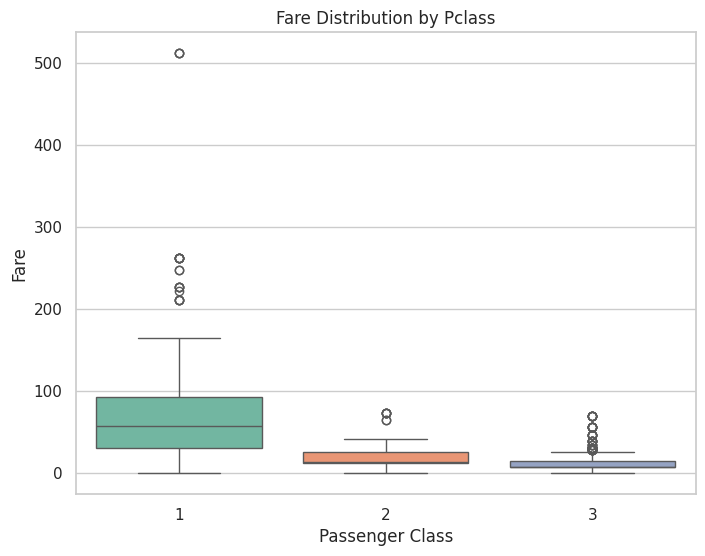

In [24]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Pclass', y='Fare', data=df, palette='Set2')
plt.title('Fare Distribution by Pclass')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.show()

Explanation  of above graph

Passenger Class 1:

The fare distribution for Passenger Class 1 is the highest, with a median fare around 80-100.

There are a few outliers with fares above 300, indicating some very high-priced tickets in this class.

Passenger Class 2:

The fare distribution for Passenger Class 2 is lower than Class 1, with a median fare around 15-20.

The range of fares is also smaller compared to Class 1, with fewer outliers.

Passenger Class 3:

The fare distribution for Passenger Class 3 is the lowest, with a median fare around 8-10.

The range of fares is also the smallest among the three classes, with fewer outliers.

*b) Boxplot of Age by Survived*

<ipython-input-25-045ef5a5d975>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=df, palette='Set3')


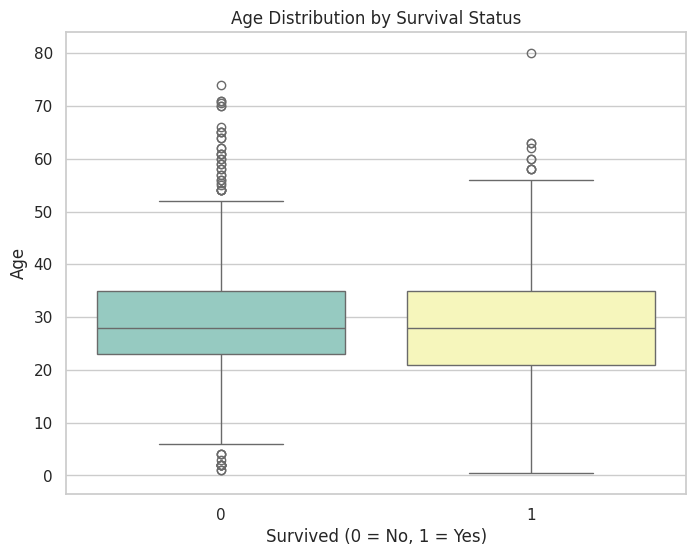

In [25]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Age', data=df, palette='Set3')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.show()

Explanation of above graph:

Age Distribution for Survivors:

The box plot for the "Survived" group (value 1) shows a relatively wide distribution of ages, with a median age around 28 years.
The box extends from around 20 to 40 years, indicating that the majority of survivors were within this age range.
There are also some outliers at both the younger and older ends of the age spectrum, suggesting that passengers of various ages were able to survive the Titanic disaster.

Age Distribution for Non-Survivors:

The box plot for the "Not Survived" group (value 0) has a more compact distribution, with the majority of ages concentrated in the 20-40 year range.
The median age for non-survivors is slightly lower than that of survivors, around 25-30 years.
The box plot for non-survivors is also more symmetrical, without the long tails seen in the "Survived" group.

Interpretation:

The box plots reveal that the age distribution of Titanic passengers who survived the disaster was broader compared to those who did not survive.
This suggests that passengers of a wider range of ages had a better chance of survival, while the younger and middle-aged passengers were more vulnerable.
The differences in age distribution between the two groups may be attributed to factors such as physical ability, access to resources, and prioritization during the evacuation process.


** Scatterplots (to explore relationships between pairs of features)**

🔸 ** SibSp vs. Parch (with survival hue)**

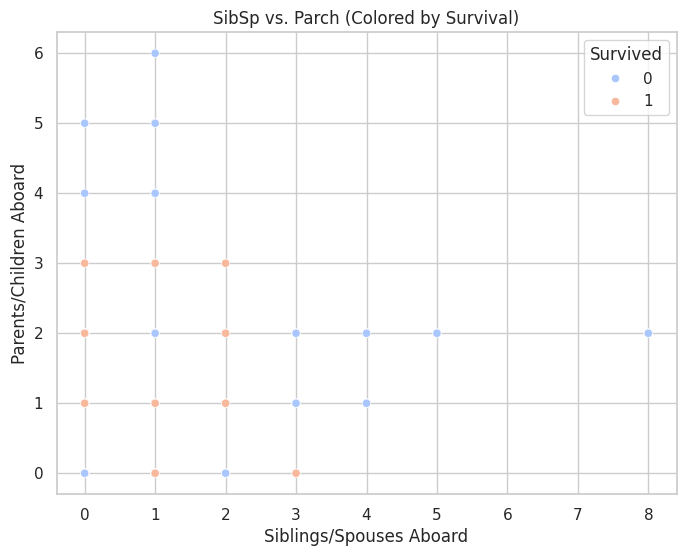

In [26]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='SibSp', y='Parch', data=df, hue='Survived', palette='coolwarm')
plt.title('SibSp vs. Parch (Colored by Survival)')
plt.xlabel('Siblings/Spouses Aboard')
plt.ylabel('Parents/Children Aboard')
plt.grid(True)
plt.show()

Explanation of above graph:

Survival Status Visualization:

The plot uses a color-coding scheme to distinguish between passengers who survived (blue) and those who did not (orange).
This allows for a clear visual comparison of the distribution of data points between the two survival groups.

Relationship between SibSp and Parch:

The scatter plot shows the relationship between the number of siblings/spouses aboard (SibSp) and the number of parents/children aboard (Parch) for each passenger.
The data points are scattered across the plot, indicating that there is no strong linear correlation between these two variables.

Survival Patterns:

The blue data points (survived passengers) are more concentrated in the lower-left quadrant of the plot, indicating that passengers with fewer siblings/spouses and fewer parents/children aboard had a higher chance of survival.
Conversely, the orange data points (non-survived passengers) are more widely distributed across the plot, suggesting that passengers with a wider range of family sizes had a lower chance of survival.


Interpretation:

The scatter plot reveals that the survival of Titanic passengers was not solely dependent on the number of family members aboard, but rather a complex interplay of various factors.
However, the clustering of survived passengers in the lower-left quadrant suggests that having fewer immediate family members aboard may have increased one's chances of survival during the disaster.

***🔁 4. Multivariate & Correlation Analysis***

**🛠️ Use sns.heatmap(), sns.pairplot() to discover deep patterns**

In [27]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

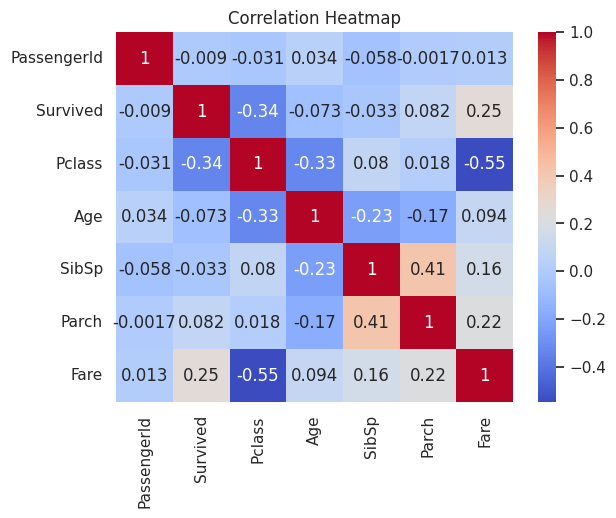

In [ ]:
# Correlation Heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Explanation of above graph:

Feature Correlations:

The heatmap displays the correlation coefficients between the different features, including Passenger ID, Survival Status, Passenger Class, Age, Siblings/Spouses Aboard, Parents/Children Aboard, and Fare.
The correlation coefficients range from -1 to 1, with darker shades of red indicating stronger positive correlations and darker shades of blue indicating stronger negative correlations.
Survival Status Correlations:

The "Survived" feature shows a strong negative correlation with "Pclass" (Passenger Class), indicating that passengers in higher classes were more likely to survive the Titanic disaster.
"Survived" also shows a moderate positive correlation with "Fare", suggesting that passengers who paid higher fares were more likely to survive.
Age and Family Correlations:

Age has a moderate negative correlation with "Survived", implying that younger passengers had a better chance of survival.
"SibSp" (Siblings/Spouses Aboard) and "Parch" (Parents/Children Aboard) both have weak positive correlations with "Survived", suggesting that the number of family members aboard did not have a significant impact on survival.
Passenger ID Correlation:

The "PassengerId" feature shows negligible correlations with all other features, indicating that it is not a meaningful predictor of survival or other passenger characteristics.


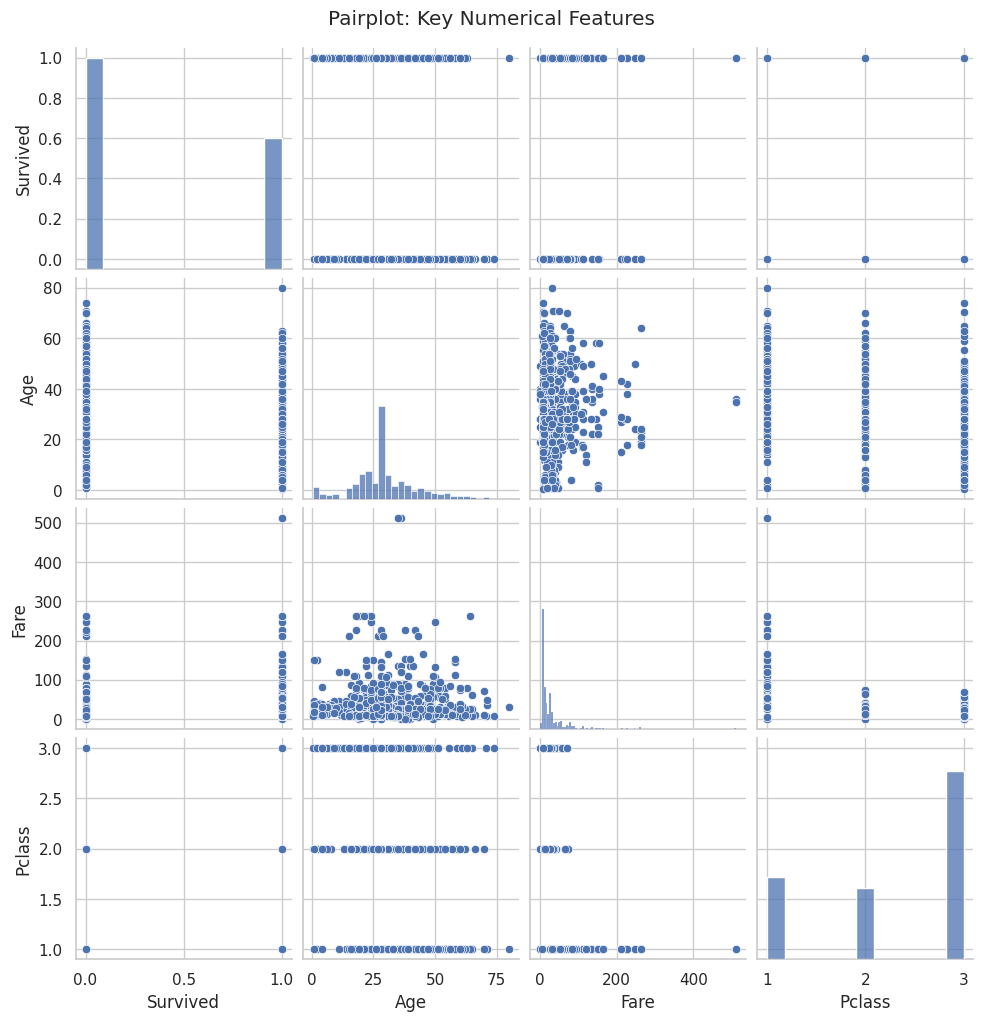

In [28]:
# Pairplot
sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']])
plt.suptitle("Pairplot: Key Numerical Features", y=1.02)
plt.show()

Explanation of Above Graph:

Survived vs. Other Features:

The scatter plot of "Survived" vs. other features shows a clear separation between survived and non-survived passengers.

Passengers who survived tend to have lower ages and higher fares, while those who did not survive are more evenly distributed across the age and fare ranges.

The relationship between "Survived" and "Pclass" is also evident, with the majority of survived passengers belonging to the lower Pclass (1 and 2).

Age vs. Other Features:

The scatter plot of "Age" vs. other features reveals an interesting distribution.

Younger passengers (under 40 years old) have a wider range of fares and Pclass, while older passengers tend to be concentrated in the higher Pclass and lower fare ranges.

Fare vs. Pclass:

The scatter plot of "Fare" vs. "Pclass" shows a clear positive correlation, with higher fares associated with lower Pclass (i.e., higher class).
This suggests that passengers who paid higher fares were more likely to be in the upper classes.

Overall Patterns:

The pairplot provides a comprehensive view of the relationships between the key numerical features, highlighting the complex interplay between survival, age, fare, and passenger class.
It suggests that factors such as age, fare, and class played a significant role in the survival outcomes of Titanic passengers.

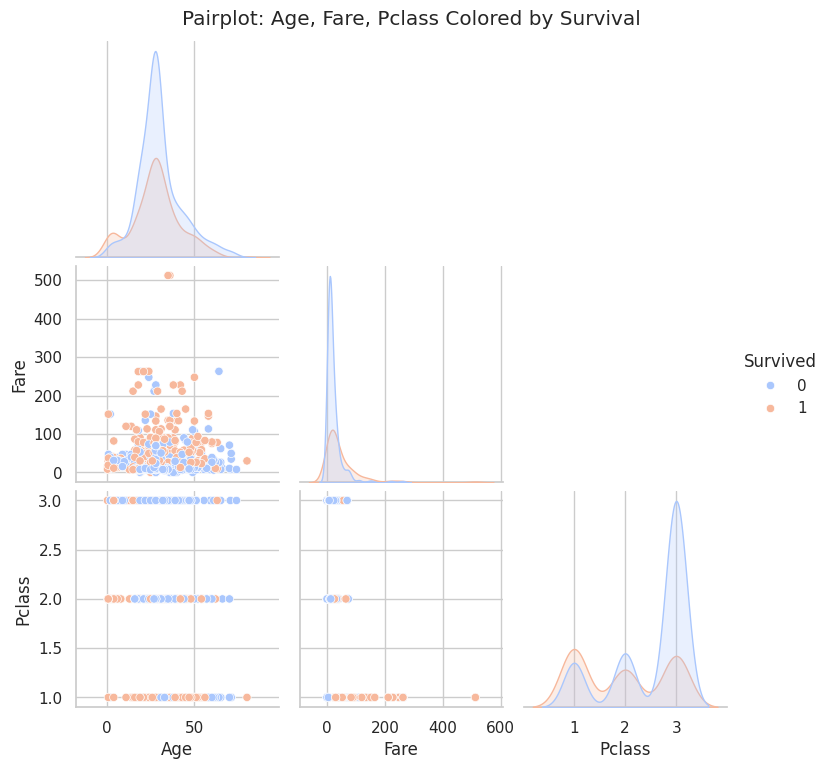

In [30]:
# Enhanced pairplot
sns.pairplot(df[['Survived', 'Age', 'Fare', 'Pclass']], hue='Survived', palette='coolwarm', corner=True)
plt.suptitle("Pairplot: Age, Fare, Pclass Colored by Survival", y=1.02)
plt.show()

Explanation of Above Graph:

Age vs. Survival:

The scatter plot of Age vs. Fare and Pclass shows a bimodal distribution, with a concentration of younger passengers (under 50 years old) and a smaller group of older passengers.
Survived passengers are predominantly in the younger age group, while non-survived passengers are more evenly distributed across the age range.
Fare vs. Survival:

The scatter plot of Fare vs. Age and Pclass reveals a strong correlation between higher fares and survival.
Passengers who paid higher fares are more likely to have survived, as indicated by the larger concentration of blue points (survived) in the higher fare range.
Pclass vs. Survival:

The scatter plot of Pclass vs. Age and Fare shows a clear separation between the different passenger classes.
Passengers in the lower Pclass (1 and 2) are more likely to have survived, as indicated by the higher proportion of blue points in these classes.
Passengers in the higher Pclass (3) are more evenly distributed between survived and non-survived, with a larger concentration of orange points (non-survived).
Overall Patterns:

The pairplot provides a comprehensive view of the interplay between the key features and the survival outcome of Titanic passengers.
It suggests that factors such as age, fare, and passenger class were significant determinants of survival, with younger passengers who paid higher fares and were in the lower passenger classes having a higher chance of survival.

**✅ Outcome

Learned how to use .describe(), .value_counts(), .info() for quick overviews.

Built effective univariate and bivariate visualizations.

Analyzed relationships and trends using pairplots and heatmaps.

Practiced interpreting visual data into actionable insights.

Gained confidence identifying patterns, trends, and anomalies.**

**🧾 Conclusion of Titanic EDA

The EDA on the Titanic dataset provided several key insights:

Survival Rates were influenced by multiple factors:

Gender: Females had a significantly higher survival rate compared to males.

Passenger Class (Pclass): First-class passengers had the highest chance of survival, while third-class passengers had the lowest.

Age: Younger passengers, especially children, had better chances of survival.

Fare and Class were positively correlated — passengers in higher classes paid more fares.

Family Size (SibSp and Parch): Passengers traveling with 1–2 family members had better survival odds compared to those traveling alone or with large families.

Heatmap and Pairplot Analyses revealed:

Moderate correlation between Fare and Pclass.

Weak correlation between age and survival, but clear separations appeared when combined with other features.**